# Pipeline de Dados — INMET
### Objetivo:
Extrair e tratar séries horárias de temperatura e radiação solar das estações meteorológicas brasileiras para análise regional de demanda de aquecimento de água.
#
### Fontes:
Banco de Dados Meteorológicos (BDMEP) — 2021 a 2025

### Plataforma:
Instituto Nacional de Meteorologia (INMET) https://portal.inmet.gov.br/dadoshistoricos


In [ ]:
# ------------------------------------------------------------
# 1. MONTAGEM DO GOOGLE DRIVE
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ------------------------------------------------------------
# 2. VERIFICAÇÃO DOS ARQUIVOS
# Confirmar que os ZIPs estão acessíveis antes de extrair
# ------------------------------------------------------------
import os

pasta_drive = "/content/drive/MyDrive/dados_projeto_ciencia_dados"

print("Arquivos disponíveis na pasta:")
for a in sorted(os.listdir(pasta_drive)):
    print(f"  {a}")


Arquivos disponíveis na pasta:
  2021.zip
  2022.zip
  2023.zip
  2024.zip
  2025.zip


In [ ]:
# ------------------------------------------------------------
# 3. IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------
import zipfile
import re
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO


In [ ]:
# ------------------------------------------------------------
# 4. CONFIGURAÇÃO
# Colunas de interesse e mapeamento de nomes
# ------------------------------------------------------------

COLUNAS_UTEIS = [
    "Data",
    "Hora UTC",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)",
    "RADIACAO GLOBAL (Kj/m²)"
]

RENOMEAR = {
    "Data"                                          : "data",
    "Hora UTC"                                      : "hora",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)" : "temp_bulbo_seco",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)"   : "temp_minima",
    "RADIACAO GLOBAL (Kj/m²)"                      : "radiacao_global"
}


In [ ]:
# ------------------------------------------------------------
# 5. COLETA DOS DADOS
# Extração de todos os CSVs dentro dos ZIPs por ano
# ------------------------------------------------------------

def extrair_metadados(nome_arquivo):
    """
    Extrai região, UF, código e nome da estação
    a partir do nome do arquivo.
    Padrão: INMET_CO_DF_A001_BRASILIA_01-01-2021_A_31-12-2021.CSV
    """
    nome   = os.path.basename(nome_arquivo).replace(".CSV", "")
    partes = nome.split("_")
    regiao = partes[1]
    uf     = partes[2]
    codigo = partes[3]

    match = re.search(r'(\d{2}-\d{2}-\d{4})_A_(\d{2}-\d{2}-\d{4})', nome)
    if match:
        idx_codigo = nome.find(codigo) + len(codigo) + 1
        idx_data   = nome.find(match.group(1)) - 1
        estacao    = nome[idx_codigo:idx_data]
    else:
        estacao = "DESCONHECIDA"

    return {
        "regiao"  : regiao,
        "uf"      : uf,
        "codigo"  : codigo,
        "estacao" : estacao
    }


In [ ]:
def ler_arquivo_inmet(z, nome_arquivo):
    """
    Lê um arquivo CSV do INMET dentro de um ZipFile.
    Pula as 8 linhas de metadados antes do cabeçalho real.
    Mantém apenas as colunas úteis ao projeto.
    """
    meta = extrair_metadados(nome_arquivo)

    with z.open(nome_arquivo) as f:
        conteudo = f.read().decode("latin1")

    df = pd.read_csv(
        StringIO(conteudo),
        sep=";",
        skiprows=8,
        decimal=",",
        low_memory=False
    )

    colunas_presentes = [c for c in COLUNAS_UTEIS if c in df.columns]
    df = df[colunas_presentes].copy()
    df = df.rename(columns=RENOMEAR)

    df["regiao"]  = meta["regiao"]
    df["uf"]      = meta["uf"]
    df["codigo"]  = meta["codigo"]
    df["estacao"] = meta["estacao"]

    return df

In [ ]:
# Percorrer todos os ZIPs disponíveis
zips = sorted([f for f in os.listdir(pasta_drive) if f.endswith(".zip")])
print(f"ZIPs encontrados: {zips}\n")

lista_dfs = []

for nome_zip in zips:
    caminho_zip = os.path.join(pasta_drive, nome_zip)
    print(f"Processando {nome_zip}...")

    with zipfile.ZipFile(caminho_zip, "r") as z:
        csvs = [a for a in z.namelist() if a.endswith(".CSV")]
        print(f"  {len(csvs)} estações")

        for csv in csvs:
            try:
                df_estacao = ler_arquivo_inmet(z, csv)
                lista_dfs.append(df_estacao)
            except Exception as e:
                print(f"  Erro em {csv}: {e}")

df_inmet_bruto = pd.concat(lista_dfs, ignore_index=True)
print(f"\nExtração concluída. Shape bruto: {df_inmet_bruto.shape}")


ZIPs encontrados: ['2021.zip', '2022.zip', '2023.zip', '2024.zip', '2025.zip']

Processando 2021.zip...
  588 estações
Processando 2022.zip...
  567 estações
Processando 2023.zip...
  567 estações
Processando 2024.zip...
  565 estações
Processando 2025.zip...
  594 estações

Extração concluída. Shape bruto: (25049928, 9)


In [ ]:
# ------------------------------------------------------------
# 6. INSPEÇÃO INICIAL
# Verificar estrutura, tipos e volume dos dados brutos
# ------------------------------------------------------------

print(df_inmet_bruto.head())
print(df_inmet_bruto.info())
print(df_inmet_bruto.describe())

         data      hora  temp_bulbo_seco  temp_minima  radiacao_global regiao  \
0  2021/01/01  0000 UTC             20.9         20.8              NaN     CO   
1  2021/01/01  0100 UTC             20.5         19.5              NaN     CO   
2  2021/01/01  0200 UTC             19.6         19.6              NaN     CO   
3  2021/01/01  0300 UTC             19.4         19.3              NaN     CO   
4  2021/01/01  0400 UTC             18.7         18.6              NaN     CO   

   uf codigo   estacao  
0  DF   A001  BRASILIA  
1  DF   A001  BRASILIA  
2  DF   A001  BRASILIA  
3  DF   A001  BRASILIA  
4  DF   A001  BRASILIA  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25049928 entries, 0 to 25049927
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   data             object 
 1   hora             object 
 2   temp_bulbo_seco  float64
 3   temp_minima      float64
 4   radiacao_global  float64
 5   regiao           object 
 6   uf  

In [ ]:
# ------------------------------------------------------------
# 7. LIMPEZA E TRATAMENTO
# Converter tipos, tratar valores ausentes e inválidos
# ------------------------------------------------------------

df_inmet = df_inmet_bruto.copy()

# Converter data para datetime
df_inmet["data"] = pd.to_datetime(df_inmet["data"], format="%Y/%m/%d", errors="coerce")

# Extrair ano e mês para agregação posterior
df_inmet["ano"] = df_inmet["data"].dt.year
df_inmet["mes"] = df_inmet["data"].dt.month

# Converter colunas numéricas — valores ausentes viram NaN
for col in ["temp_bulbo_seco", "temp_minima", "radiacao_global"]:
    df_inmet[col] = pd.to_numeric(df_inmet[col], errors="coerce")

# Remover registros sem data válida
antes = len(df_inmet)
df_inmet = df_inmet.dropna(subset=["data"]).reset_index(drop=True)
print(f"Registros removidos por data inválida: {antes - len(df_inmet)}")

# Remover temperaturas fora do intervalo plausível para o Brasil
df_inmet = df_inmet[
    df_inmet["temp_bulbo_seco"].between(-10, 50) |
    df_inmet["temp_bulbo_seco"].isna()
].reset_index(drop=True)

print(f"\nShape após limpeza: {df_inmet.shape}")
print(df_inmet.describe())

Registros removidos por data inválida: 0

Shape após limpeza: (25049928, 11)
                                data  temp_bulbo_seco   temp_minima  \
count                       25049928     1.803155e+07  1.799361e+07   
mean   2023-06-29 02:18:19.721681152     2.335065e+01  2.269750e+01   
min              2021-01-01 00:00:00    -9.200000e+00 -9.900000e+00   
25%              2022-03-24 00:00:00     1.990000e+01  1.940000e+01   
50%              2023-06-28 00:00:00     2.350000e+01  2.300000e+01   
75%              2024-10-01 00:00:00     2.720000e+01  2.630000e+01   
max              2025-12-31 00:00:00     4.500000e+01  4.380000e+01   
std                              NaN     5.780973e+00  5.634249e+00   

       radiacao_global           ano           mes  
count     1.095852e+07  2.504993e+07  2.504993e+07  
mean      1.251121e+03  2.022990e+03  6.536580e+00  
min       0.000000e+00  2.021000e+03  1.000000e+00  
25%       1.373000e+02  2.022000e+03  4.000000e+00  
50%       1.010500

In [ ]:
# ------------------------------------------------------------
# 8. AGREGAÇÃO — DIÁRIA POR ESTAÇÃO, DEPOIS MENSAL POR UF
# A agregação passa primeiro pelo DIA para preservar o sinal das
# noites frias (temperatura mínima diária — relevante para o pico
# de demanda noturna) e converter a radiação em acumulado diário.
# ------------------------------------------------------------
import numpy as np

# Guarda contra sentinelas/valores implausíveis
df_inmet.loc[~df_inmet["temp_minima"].between(-20, 50), "temp_minima"] = np.nan
df_inmet.loc[df_inmet["radiacao_global"] < 0, "radiacao_global"] = np.nan

# 8.1 — agregação diária por estação
df_diario = (
    df_inmet
    .groupby(["uf", "ano", "mes", "codigo", "data"])
    .agg(
        t_media_dia = ("temp_bulbo_seco", "mean"),
        t_min_dia   = ("temp_minima",     "min"),    # temperatura mínima do dia
        t_max_dia   = ("temp_bulbo_seco", "max"),
        rad_dia_kj  = ("radiacao_global", "sum"),     # Kj/m² acumulados no dia
        rad_n       = ("radiacao_global", "count"),
    )
    .reset_index()
)
# Kj/m²/dia -> kWh/m²/dia (dias sem leitura de radiação ficam NaN)
df_diario["rad_dia_kwh"] = np.where(
    df_diario["rad_n"] > 0, df_diario["rad_dia_kj"] / 3600.0, np.nan
)
df_diario["amp_dia"] = df_diario["t_max_dia"] - df_diario["t_min_dia"]

# 8.2 — agregação mensal por UF
df_mensal = (
    df_diario
    .groupby(["uf", "ano", "mes"])
    .agg(
        temp_media_mensal        = ("t_media_dia", "mean"),
        temp_minima_mensal       = ("t_min_dia",   "mean"),   # média das mínimas diárias
        temp_minima_absoluta     = ("t_min_dia",   "min"),    # noite mais fria do mês
        radiacao_kwh_m2_dia      = ("rad_dia_kwh", "mean"),   # irradiação diária média (kWh/m²/dia)
        amplitude_termica_diaria = ("amp_dia",     "mean"),   # amplitude térmica diária média
        n_dias                   = ("data",        "nunique"),
    )
    .reset_index()
)

print(f"\nShape agregado mensal: {df_mensal.shape}")
print(df_mensal.head(10))


Shape agregado mensal: (1620, 7)
   uf   ano  mes  temp_media_mensal  temp_minima_mensal  radiacao_media  \
0  AC  2021    1          25.245924           24.717591     1731.980228   
1  AC  2021    2          25.298382           24.819485     1233.204335   
2  AC  2021    3          24.906769           24.389837     1221.306015   
3  AC  2021    4          25.203226           24.533209     1367.560377   
4  AC  2021    5          24.775527           24.088759     1300.705675   
5  AC  2021    6          24.738205           23.984774     1323.112885   
6  AC  2021    7          23.297629           22.458906     1420.310565   
7  AC  2021    8          24.888172           24.040726     1321.428827   
8  AC  2021    9          25.718750           24.977500     1380.027763   
9  AC  2021   10          25.562231           24.907930     1426.579156   

   n_leituras  
0        1570  
1        1174  
2        1108  
3         806  
4         854  
5         780  
6         717  
7         74

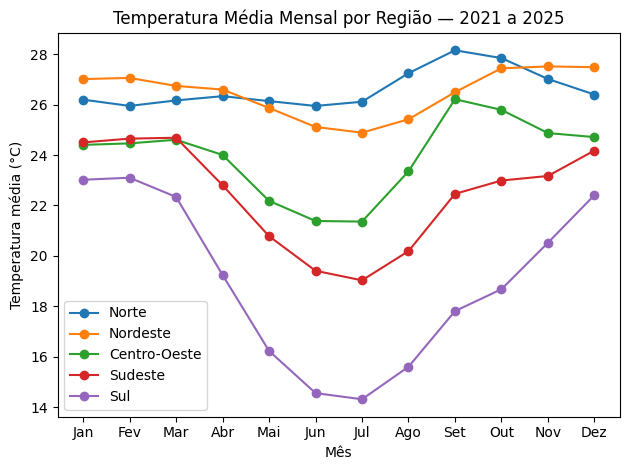

In [ ]:
# ------------------------------------------------------------
# 9. VISUALIZAÇÕES INICIAIS
# Qual a variação de temperatura média mensal por região?
# ------------------------------------------------------------

regioes = {
    "Norte"        : ["AM", "PA", "AC", "RO", "RR", "AP", "TO"],
    "Nordeste"     : ["MA", "PI", "CE", "RN", "PB", "PE", "AL", "SE", "BA"],
    "Centro-Oeste" : ["MT", "MS", "GO", "DF"],
    "Sudeste"      : ["SP", "RJ", "MG", "ES"],
    "Sul"          : ["PR", "SC", "RS"]
}

mapa_regiao = {
    uf: regiao
    for regiao, ufs in regioes.items()
    for uf in ufs
}

df_mensal["regiao_br"] = df_mensal["uf"].map(mapa_regiao)

df_temp_regiao = (
    df_mensal
    .groupby(["regiao_br", "mes"])["temp_media_mensal"]
    .mean()
    .reset_index()
)

for regiao in regioes:
    dados = df_temp_regiao[df_temp_regiao["regiao_br"] == regiao]
    plt.plot(dados["mes"], dados["temp_media_mensal"], marker="o", label=regiao)

plt.title("Temperatura Média Mensal por Região — 2021 a 2025")
plt.xlabel("Mês")
plt.ylabel("Temperatura média (°C)")
plt.xticks(range(1, 13), ["Jan","Fev","Mar","Abr","Mai","Jun",
                            "Jul","Ago","Set","Out","Nov","Dez"])
plt.legend()
plt.tight_layout()
plt.show()


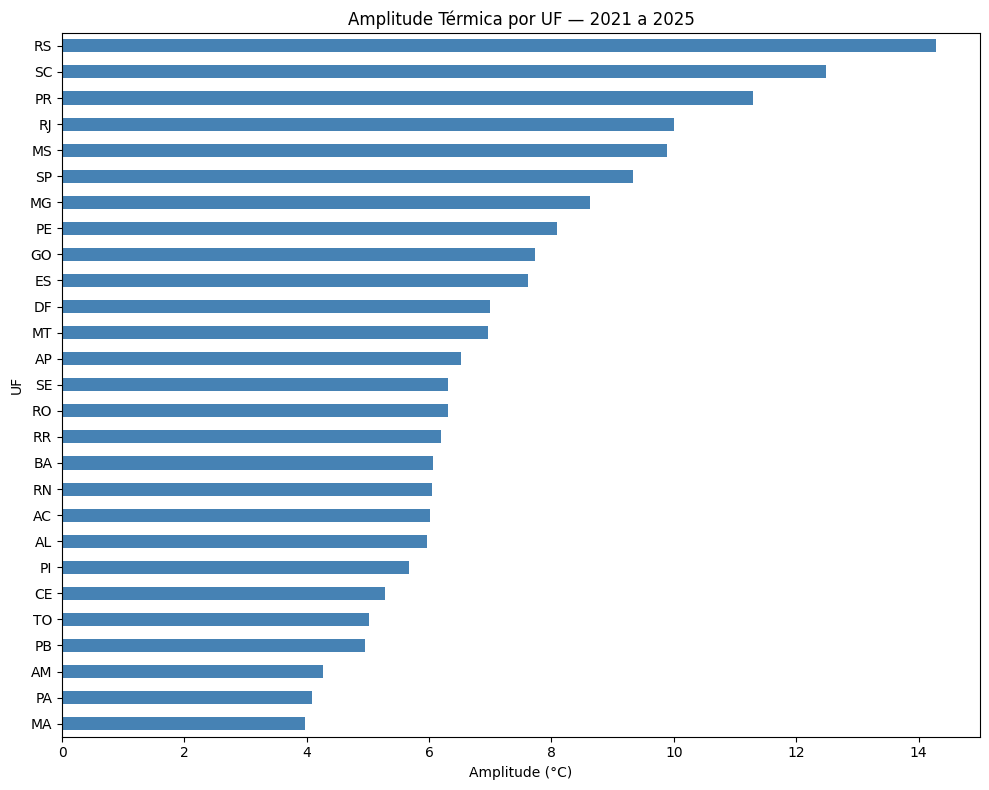

In [ ]:
# ------------------------------------------------------------
# Qual a amplitude térmica DIÁRIA média por UF?
# (média da diferença diária entre temperatura máxima e mínima)
# ------------------------------------------------------------
df_amplitude = (
    df_mensal
    .groupby("uf")["amplitude_termica_diaria"]
    .mean()
    .sort_values(ascending=True)
)

df_amplitude.plot(kind="barh", figsize=(10, 8), color="steelblue")
plt.title("Amplitude Térmica Diária Média por UF — 2021 a 2025")
plt.xlabel("Amplitude térmica diária (°C)")
plt.ylabel("UF")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 10. EXPORTAÇÃO
# ------------------------------------------------------------

df_inmet.to_csv(
    "/content/drive/MyDrive/dados_projeto_ciencia_dados/inmet_horario_tratado.csv",
    index=False,
    encoding="utf-8-sig"
)

df_mensal.to_csv(
    "/content/drive/MyDrive/dados_projeto_ciencia_dados/inmet_mensal_por_uf.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos exportados com sucesso.")

Arquivos exportados com sucesso.


In [ ]:
# ============================================================
# CÁLCULO DA PROXY DE COP REGIONAL
# Metodologia: When2Heat (Ruhnau et al., 2019) — Equação 4
# Tipo de bomba: ASHP (ar-água) para aquecimento de água
# ============================================================

# ------------------------------------------------------------
# PARÂMETROS DO WHEN2HEAT
# Bomba de calor ar-água (ASHP) — aquecimento de água
# T_sink (temperatura do sumidouro) = 50°C constante
# conforme medições de campo alemãs (Günther et al., 2014)
# Fator de correção real = 0.85 (ajuste para condições reais)
# ΔT mínimo = 15K (limite dos dados de fabricante)
# ------------------------------------------------------------

T_SINK         = 50    # temperatura da água aquecida (°C)
DELTA_T_MIN    = 15    # diferença mínima entre fonte e sumidouro (K)
FATOR_CORRECAO = 0.85  # correção real-world conforme Günther et al.


def calcular_cop_ashp(temp_fonte):
    """
    Calcula o COP de uma bomba de calor ar-água (ASHP)
    para aquecimento de água usando a equação quadrática
    do When2Heat (Equação 4 — Ruhnau et al., 2019).

    COP = 6.08 - 0.09 × ΔT + 0.0005 × ΔT²

    Onde ΔT = T_sink - T_source, com mínimo de 15K.
    O resultado é multiplicado pelo fator de correção 0.85
    para aproximar condições reais de operação.
    """
    delta_t = T_SINK - temp_fonte
    delta_t = max(delta_t, DELTA_T_MIN)   # aplica mínimo de 15K

    cop = 6.08 - 0.09 * delta_t + 0.0005 * (delta_t ** 2)
    return round(cop * FATOR_CORRECAO, 4)


In [ ]:
# Aplicar sobre cada linha do df_mensal
df_mensal["cop_ashp_agua"] = df_mensal["temp_media_mensal"].apply(
    calcular_cop_ashp
)

print("COP calculado com sucesso.")
print(df_mensal[["uf", "ano", "mes", "temp_media_mensal", "cop_ashp_agua"]].head(12))
print(f"\nCOP mínimo: {df_mensal['cop_ashp_agua'].min()}")
print(f"COP máximo: {df_mensal['cop_ashp_agua'].max()}")
print(f"COP médio:  {df_mensal['cop_ashp_agua'].mean():.4f}")

COP calculado com sucesso.
    uf   ano  mes  temp_media_mensal  cop_ashp_agua
0   AC  2021    1          25.245924         3.5347
1   AC  2021    2          25.298382         3.5376
2   AC  2021    3          24.906769         3.5160
3   AC  2021    4          25.203226         3.5324
4   AC  2021    5          24.775527         3.5087
5   AC  2021    6          24.738205         3.5067
6   AC  2021    7          23.297629         3.4283
7   AC  2021    8          24.888172         3.5150
8   AC  2021    9          25.718750         3.5611
9   AC  2021   10          25.562231         3.5523
10  AC  2021   11          25.301250         3.5378
11  AC  2021   12          25.425672         3.5447

COP mínimo: 2.8491
COP máximo: 3.9185
COP médio:  3.5077


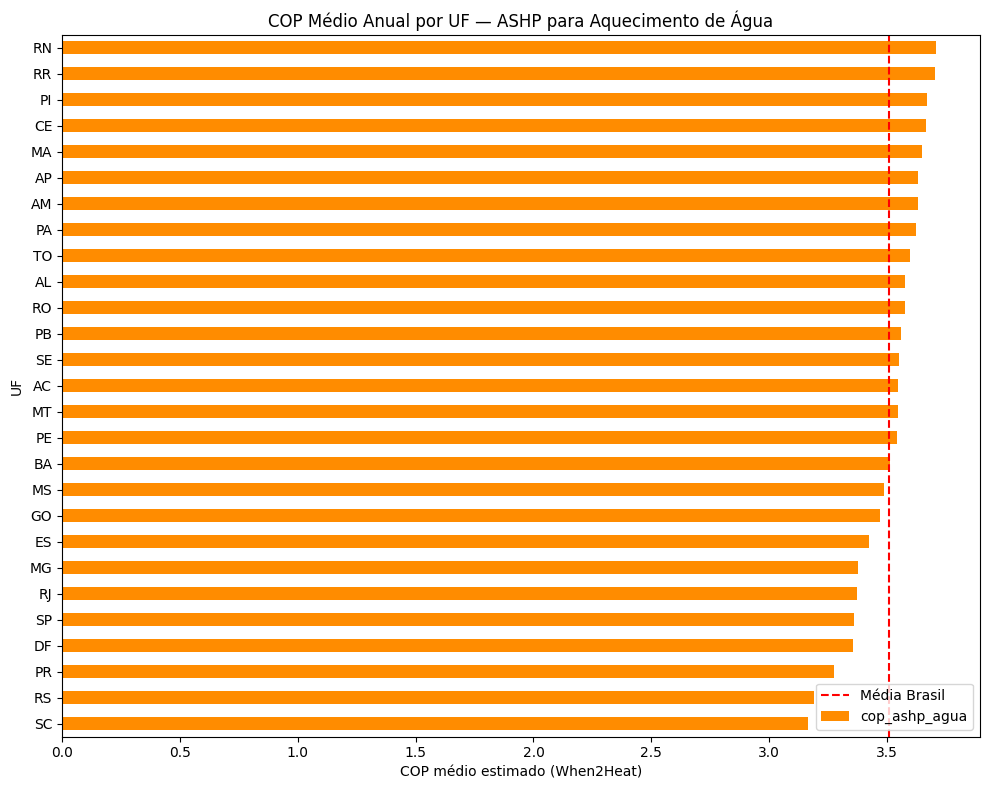

In [ ]:
# ------------------------------------------------------------
# VISUALIZAÇÃO
# Qual região tem maior COP médio anual?
# (maior COP = bomba de calor mais eficiente = clima mais quente)
# ------------------------------------------------------------

df_cop_uf = (
    df_mensal
    .groupby("uf")["cop_ashp_agua"]
    .mean()
    .sort_values(ascending=True)
)

df_cop_uf.plot(kind="barh", figsize=(10, 8), color="darkorange")
plt.title("COP Médio Anual por UF — ASHP para Aquecimento de Água")
plt.xlabel("COP médio estimado (When2Heat)")
plt.ylabel("UF")
plt.axvline(x=df_cop_uf.mean(), color="red", linestyle="--", label="Média Brasil")
plt.legend()
plt.tight_layout()
plt.show()


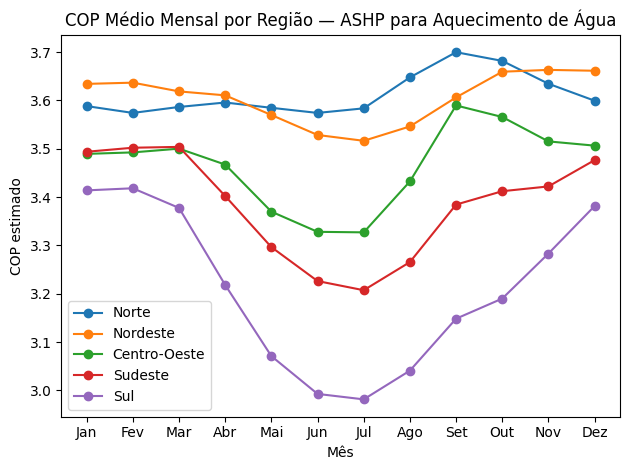

In [ ]:
# Como o COP varia ao longo do ano por região?
df_cop_regiao = (
    df_mensal
    .groupby(["regiao_br", "mes"])["cop_ashp_agua"]
    .mean()
    .reset_index()
)

for regiao in regioes:
    dados = df_cop_regiao[df_cop_regiao["regiao_br"] == regiao]
    plt.plot(dados["mes"], dados["cop_ashp_agua"], marker="o", label=regiao)

plt.title("COP Médio Mensal por Região — ASHP para Aquecimento de Água")
plt.xlabel("Mês")
plt.ylabel("COP estimado")
plt.xticks(range(1, 13), ["Jan","Fev","Mar","Abr","Mai","Jun",
                            "Jul","Ago","Set","Out","Nov","Dez"])
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CÁLCULO DA APTIDÃO SOLAR REGIONAL
# Coletor solar de placa plana para aquecimento de água
# Métrica simétrica ao COP: ambas medem a performance física
# de um dos produtos do portfólio (solar e bomba de calor).
# ============================================================
# Energia útil entregue por m² de coletor por dia:
#   energia_util = irradiação incidente × eficiência do coletor
# A eficiência típica de coletores planos para aquecimento de
# água residencial fica em torno de 50% em condições reais
# (ABNT NBR 15569 e dados de fabricantes).
EFICIENCIA_COLETOR_SOLAR = 0.50  # fração da irradiação convertida em calor útil

df_mensal["energia_solar_util_kwh_m2_dia"] = (
    df_mensal["radiacao_kwh_m2_dia"] * EFICIENCIA_COLETOR_SOLAR
)

print("Aptidão solar calculada (kWh/m²/dia de calor útil).")
print(df_mensal[["uf","ano","mes","radiacao_kwh_m2_dia",
                 "energia_solar_util_kwh_m2_dia"]].head())
print(f"\nMédia Brasil: {df_mensal['energia_solar_util_kwh_m2_dia'].mean():.2f} kWh/m²/dia")

In [ ]:
# ------------------------------------------------------------
# VISUALIZAÇÃO — Qual UF tem maior aptidão solar média?
# (maior energia útil = coletor solar rende mais)
# ------------------------------------------------------------
df_solar_uf = (
    df_mensal.groupby("uf")["energia_solar_util_kwh_m2_dia"].mean().sort_values()
)
df_solar_uf.plot(kind="barh", figsize=(10, 8), color="goldenrod")
plt.title("Aptidão Solar Média por UF — calor útil de coletor solar")
plt.xlabel("Energia útil estimada (kWh/m²/dia)")
plt.ylabel("UF")
plt.axvline(df_solar_uf.mean(), color="red", linestyle="--", label="Média Brasil")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ------------------------------------------------------------
# EXPORTAÇÃO — atualizar o arquivo mensal com o COP
# ------------------------------------------------------------

df_mensal.to_csv(
    "/content/drive/MyDrive/dados_projeto_ciencia_dados/inmet_mensal_por_uf.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo atualizado com a coluna cop_ashp_agua.")

Arquivo atualizado com a coluna cop_ashp_agua.
